In [1]:
import numpy as np
import cv2
from PIL import Image

from numba import jit

In [2]:
@jit(nopython=True)
def _search(traverse, origin, goal, size, capacity, flow):

    # set path origin and goal indexes
    goal = goal
    origin = origin
    
    # avoid double visit
    visited = np.zeros((size), np.int32)

    # a queue that states the next indexes to visit, starting with origin
    index_to_visit = 0
    to_visit = np.ones((size), np.int32)*-1
    to_visit[index_to_visit] = origin

    # mark origin as visited
    visited[origin] = 1

    # to determine the edge; predecessor:u 
    predecessor = origin

    while to_visit[index_to_visit] != -1:

        # pops the next index to visit, base of the search method chosen
        current = to_visit[index_to_visit]
        index_to_visit -= 1
        # iterates on all possible steps
        for successor in range(size):

            # a viable next step is one that was not visited and that its 
            # residual is possitive
            if visited[successor] == 0 and (capacity[current, successor] - flow[current, successor] > 0):

                # mark as visited and add to the queue to explore
                visited[successor] = 1
                index_to_visit +=1
                to_visit[index_to_visit] = successor #to_visit.append(successor)

                # adds to the traverse
                traverse[successor] = current
    return visited[goal]


@jit(nopython=True)
def max_flow(data):
    n, m = np.shape(data)
    assert n == m, "data must be square"

    # edge properties
    capacity = data
    flow = np.zeros((n, n), dtype=np.int32)

    size = n
    
    goal = size - 1
    origin = 0

    #extendend information 
    #presented_data = {}

    # initiate vars
    traverse = np.ones((size), np.int32)*-1 #[-1] * self.size
    max_flow = 0
    iter_count = 0
    path_flow = np.inf

    # before augmented path were exhusted 
    while _search(traverse, origin, goal, size, capacity, flow):

        iter_count += 1
        #presented_data[iter_count] = []

        # walk backwards, find the smallest viable flow 
        # for an augmented path
        current = goal
        while current != origin :

            #presented_data[iter_count].append(current)

            # the predecessor for the current index 
            pred = traverse[current]

            # calculate the residual, the path flow is the smaller 
            # between the edge residual and the existinf flow
            residual_flow = (capacity[pred, current] - flow[pred, current])
            path_flow = min(path_flow, residual_flow)

            current = pred

        # add the current path flow to the total flow
        max_flow += path_flow

        # walk backwards, update the flow on the edges based on 
        # the path flow
        current = goal
        while current != origin :

            # the predecessor for the current index 
            pred = traverse[current]
            flow[pred, current] += path_flow
            flow[current, pred] -= path_flow

            current = pred

    #if data:
    #return {'max_flow' : max_flow, 'iteration': [{i: [0] + presented_data[i][::-1]} for i  in range(1, iter_count+1)]}
    return max_flow

In [3]:
g = np.array([[0, 16, 13, 0, 0, 0],
        [0, 0, 10, 12, 0, 0],
        [0, 4, 0, 0, 14, 0],
        [0, 0, 9, 0, 0, 20],
        [0, 0, 0, 7, 0, 4],
        [0, 0, 0, 0, 0, 0]])

max_flow(g)

23.0

### graph for image segmentation

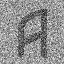

In [4]:
img = cv2.imread("1.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = img.shape
value = 50
Image.fromarray(img)

In [5]:
g = np.zeros((h*w + 2, h*w + 2), dtype = np.float32)
print(g.shape)

(4098, 4098)


In [ ]:
g[0, 1:-1] = img.flatten()
g[1:-1, -1] = 255 - img.flatten()
for i in range(h):
    for j in range(w):
        index = j + i*w + 1
        #print(index)
        # left
        if j > 0:
            left_index = j - 1 + i*w + 1
            g[left_index, index] = value
        # right
        if j < w - 1:
            right_index = j + 1 + i*w + 1
            g[right_index, index] = value
        # up
        if i > 0:
            up_index = j + (i-1)*w + 1
            g[up_index, index] = value
        # down
        if i < h - 1:
            down_index = j + (i+1)*w + 1
            g[down_index, index] = value